In [320]:
# added basic libraries for data analysis and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


> # Part 1) Load the data and make a datetime index.

In [321]:
# load the data and create a datetime index 
df = pd.read_csv('london_weather_MODIFIED.csv')

# run the file 
df.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [322]:
# run the info function 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              15341 non-null  int64  
 1   cloud_cover       14938 non-null  float64
 2   sunshine          14957 non-null  float64
 3   global_radiation  14939 non-null  float64
 4   max_temp          14951 non-null  float64
 5   mean_temp         14922 non-null  float64
 6   min_temp          14955 non-null  float64
 7   precipitation     14951 non-null  float64
 8   pressure          14953 non-null  float64
 9   snow_depth        13589 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.2 MB


> ### Convert the date column to datetime dtype.

In [323]:
# convert the date column into date time 
df['date'] = pd.to_datetime(df['date'], format = '%Y%m%d')

# run the column 
df['date']

0       1979-01-01
1       1979-01-02
2       1979-01-03
3       1979-01-04
4       1979-01-05
           ...    
15336   2020-12-27
15337   2020-12-28
15338   2020-12-29
15339   2020-12-30
15340   2020-12-31
Name: date, Length: 15341, dtype: datetime64[ns]

> ### Set the date column as the index.

In [324]:
# set the date column as the index
df = df.set_index('date')

# run the index
df.index

DatetimeIndex(['1979-01-01', '1979-01-02', '1979-01-03', '1979-01-04',
               '1979-01-05', '1979-01-06', '1979-01-07', '1979-01-08',
               '1979-01-09', '1979-01-10',
               ...
               '2020-12-22', '2020-12-23', '2020-12-24', '2020-12-25',
               '2020-12-26', '2020-12-27', '2020-12-28', '2020-12-29',
               '2020-12-30', '2020-12-31'],
              dtype='datetime64[ns]', name='date', length=15341, freq=None)

> ### Filter out only the required data:
1) Keep only data from the year 2000 or later.
2) Keep only the following features:
    - precipitation
    - mean_temp
    - min_temp
    - max_temp
    - snow_depth

In [325]:
# keep only data from the year 2000 or later
df = df.loc[df.index.year >= 2000]

# drop unnecessary features
df = df.drop(columns = df.columns[~ df.columns.isin(['precipitation', 'mean_temp', 'min_temp', 'max_temp', 'snow_depth'])])

# check the data frame 
df.head()

,max_temp,mean_temp,min_temp,precipitation,snow_depth
date,,,,,
2000-01-01,10.8,7.0,4.9,0.0,0.0
2000-01-02,11.5,7.9,5.0,0.2,0.0
2000-01-03,9.5,9.4,7.2,6.0,0.0
2000-01-04,11.0,7.0,4.4,0.2,0.0
2000-01-05,10.8,6.4,1.9,0.8,0.0


> ### Impute any missing values.

In [326]:
# check each columns null values percentage 
results = []
for col in df.columns:
    results.append({'col': col, 'missing_count': df[col].isna().sum(), 'missing_pct': round(df[col].isna().sum() / len(df), 3) * 100})
pd.DataFrame(results)

,col,missing_count,missing_pct
0,max_temp,390,5.1
1,mean_temp,419,5.5
2,min_temp,386,5.0
3,precipitation,390,5.1
4,snow_depth,1752,22.8


In [327]:
# check mean and median to decide the best method of imputation.
results = []
for col in df.columns:
    stats = df[col].describe().loc[['mean', '50%']]
    results.append({'column': col, 'mean': round(stats['mean'], 4), 'median': stats['50%']})

pd.DataFrame(results)

,column,mean,median
0,max_temp,15.8109,15.6
1,mean_temp,11.9073,11.8
2,min_temp,8.0005,8.2
3,precipitation,1.7234,0.0
4,snow_depth,0.0231,0.0


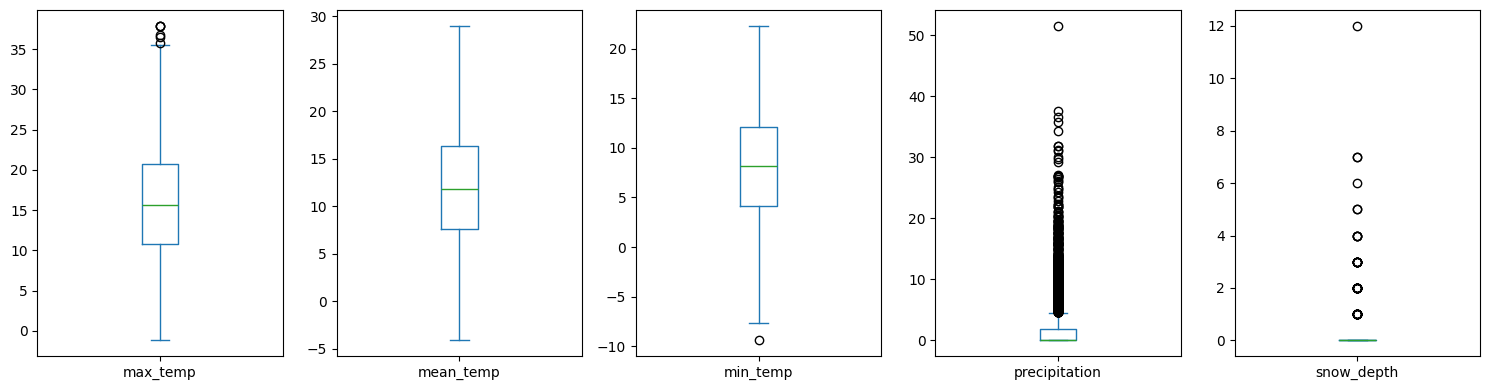

In [328]:
# plotting box plot to test outliers
df.plot(kind='box', subplots=True, layout=(1, len(df.columns)), figsize=(15, 4))
plt.tight_layout()

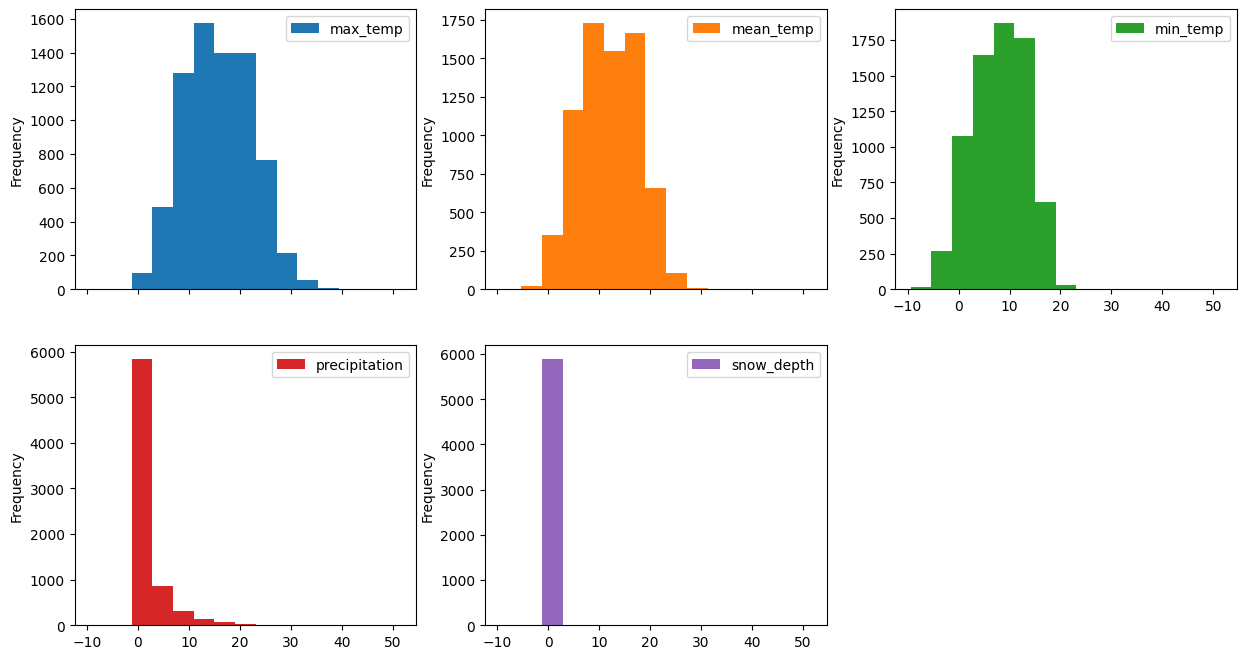

In [329]:
# examn the distribution of all columns using histogram 
df.plot(kind = 'hist', bins = 15, subplots = True, layout = (2, 3), figsize = (15, 8));

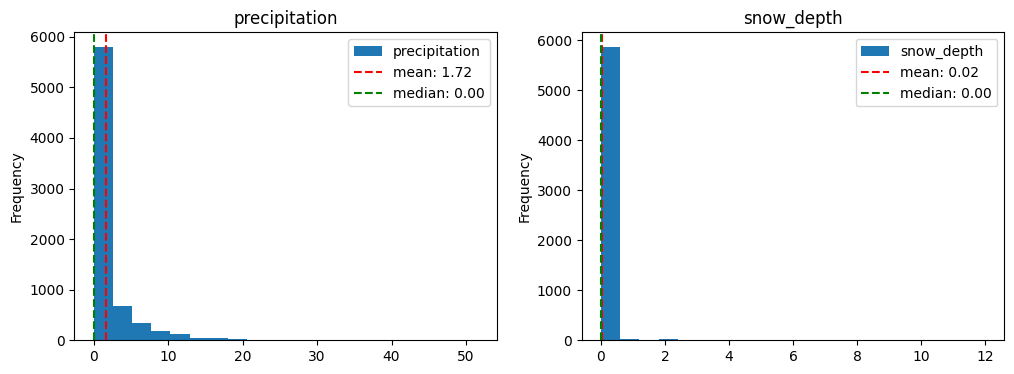

In [330]:
# extra plot to confirm my dicision about precepitation and snow depth columns imputation method
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['precipitation', 'snow_depth']):
    mean_val, median_val = df[col].mean(), df[col].median()
    df[col].plot(kind='hist', bins=20, ax=ax)
    ax.axvline(mean_val, color='red', linestyle='--', label=f'mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='--', label=f'median: {median_val:.2f}')
    ax.set_title(col)
    ax.legend()

In [331]:
# also examine the skewness of each column to decide which imputation method to use
results = []
for col in df.columns: 
    results.append({'column': col, 'Skewness': df[col].skew()})

pd.DataFrame(results)

,column,Skewness
0,max_temp,0.136454
1,mean_temp,-0.005671
2,min_temp,-0.171289
3,precipitation,3.788887
4,snow_depth,20.520432


In [332]:
# fill with approprite measure
for col in df.columns:
    if col not in ['precipitation', 'snow_depth']:
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].median())

In [333]:
# check for null values 
df.isna().sum()

max_temp         0
mean_temp        0
min_temp         0
precipitation    0
snow_depth       0
dtype: int64

### Imputation Justification

> Both `precipitation` and `snow_depth` exhibit strong right-skewness, as confirmed by their skewness scores (3.79 and 20.52, respectively) along with their box plots and histograms, which show the majority of values clustered near zero with a long tail of high-value outliers. In skewed distributions, the mean is heavily influenced by extreme values and no longer represents a typical observation, whereas the median remains robust to outliers and better reflects the central tendency of the data. For this reason, missing values in `precipitation` and `snow_depth` were imputed using the median rather than the mean.

> # Part 2) Answer the Questions with Visualizations (Using the Correct Frequency)


> ### Q1: What month had the most precipitation between 2000 through 2010?
> - Resample the precipitation column to a Monthly frequency using .sum() as the aggregation method
> - Find the date and corresponding value for the max precipitation.
> - Plot the feature and time period that corresponds to the question.
> - Add a vertical line at this date with a label that says the date (using date format: "April 2000") and the max precipitation value.


In [334]:
# copy the dataframe
first_task = df.copy()

# run the df_copy variable
first_task.head()


,max_temp,mean_temp,min_temp,precipitation,snow_depth
date,,,,,
2000-01-01,10.8,7.0,4.9,0.0,0.0
2000-01-02,11.5,7.9,5.0,0.2,0.0
2000-01-03,9.5,9.4,7.2,6.0,0.0
2000-01-04,11.0,7.0,4.4,0.2,0.0
2000-01-05,10.8,6.4,1.9,0.8,0.0


In [335]:
# Resample the precipitation column to a Monthly frequency using .sum() as the aggregation method
first_task['precipitation'].resample('MS').agg('sum')

date
2000-01-01     14.3
2000-02-01     62.2
2000-03-01     13.4
2000-04-01     71.8
2000-05-01     68.4
              ...  
2020-08-01     45.2
2020-09-01     19.2
2020-10-01    143.4
2020-11-01     47.8
2020-12-01     56.4
Freq: MS, Name: precipitation, Length: 252, dtype: float64

In [336]:
# Find the date and corresponding value for the max precipitation.
first_task.loc[first_task['precipitation'].idxmax(), ['precipitation']]

precipitation    51.6
Name: 2015-08-26 00:00:00, dtype: float64

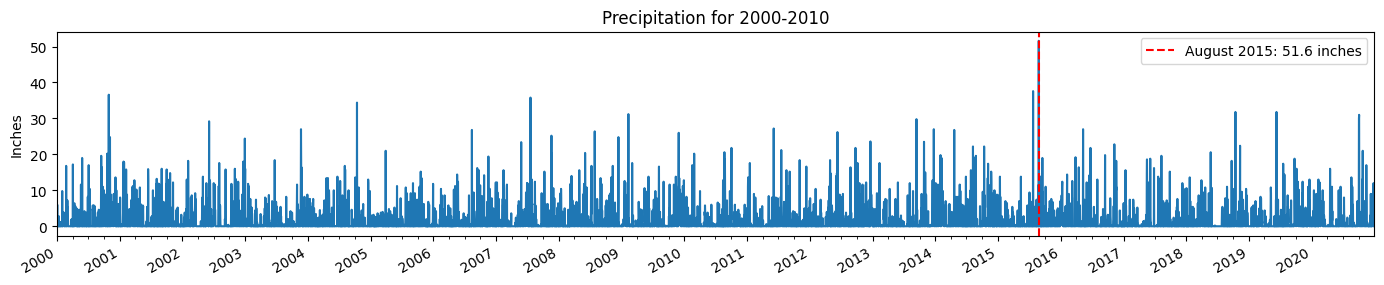

In [337]:
# visualization requirments function for Q1
def plot_first_task(ts, title = 'Title', ylabel = 'y-label'):
    fig, ax = plt.subplots(figsize=(17, 3))
    ax.plot(ts.index, ts.values)

    ax.set_xlim(ts.index.min(), ts.index.max())

    ax.set_title(title)
    ax.set_ylabel(ylabel)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.get_xticklabels(), rotation=90)

    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
    
    max_date = first_task['precipitation'].idxmax()
    max_value = first_task.loc[max_date, 'precipitation']
    ax.axvline(max_date, color='red', linestyle='--',label=f'{max_date.strftime("%B %Y")}: {max_value} inches')
    ax.legend()

    fig.autofmt_xdate()

    return fig, ax

# Plot the feature and time period that corresponds to the question.
plot_first_task(df['precipitation'], title = 'Precipitation for 2000-2010', ylabel = 'Inches');

> ### Q2: Which year between 2000-2020 had the coolest average temperature?
> - Resample the  mean_temp data to a Yearly frequency using .mean() as the aggregation method.
> - Determine the year and value for the lowest mean temp.

In [338]:
# data frame for second frame
second_task = df.copy()

# run the table
second_task.head()

,max_temp,mean_temp,min_temp,precipitation,snow_depth
date,,,,,
2000-01-01,10.8,7.0,4.9,0.0,0.0
2000-01-02,11.5,7.9,5.0,0.2,0.0
2000-01-03,9.5,9.4,7.2,6.0,0.0
2000-01-04,11.0,7.0,4.4,0.2,0.0
2000-01-05,10.8,6.4,1.9,0.8,0.0


In [339]:
# Resample the  mean_temp data to a Yearly frequency using .mean() as the aggregation method.
second_task['mean_temp'].resample('YE').agg('mean')

date
2000-12-31    11.555651
2001-12-31    11.343942
2002-12-31    12.002218
2003-12-31    12.220280
2004-12-31    11.873877
2005-12-31    11.881536
2006-12-31    12.355021
2007-12-31    12.052575
2008-12-31    11.214880
2009-12-31    11.731887
2010-12-31    10.721810
2011-12-31    12.445038
2012-12-31    11.360569
2013-12-31    11.236799
2014-12-31    12.590651
2015-12-31    12.081770
2016-12-31    11.895088
2017-12-31    12.223080
2018-12-31    12.414607
2019-12-31    12.210557
2020-12-31    12.644102
Freq: YE-DEC, Name: mean_temp, dtype: float64

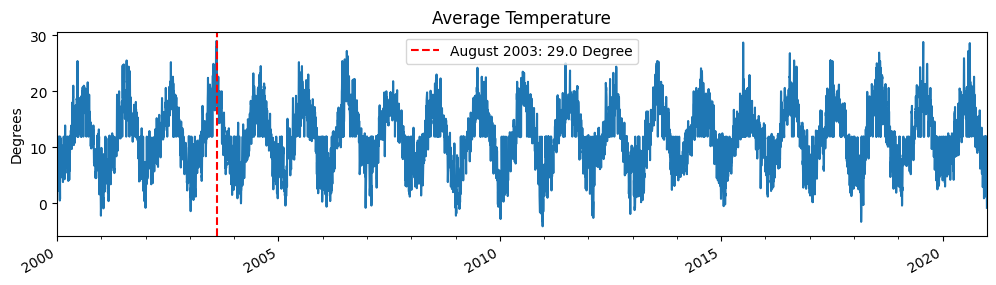

In [340]:
# visualization requirments function for Q2
def plot_second_task(ts):
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(ts.index, ts.values)
    ax.set_xlim(ts.index.min(), ts.index.max())

    ax.set_title("Average Temperature")
    ax.set_ylabel("Degrees")

    ax.xaxis.set_major_locator(mdates.YearLocator(base=5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.get_xticklabels(), rotation=90)

    ax.xaxis.set_minor_locator(mdates.YearLocator())

    max_date = first_task['mean_temp'].idxmax()
    max_value = first_task.loc[max_date, 'mean_temp']
    ax.axvline(max_date, color='red', linestyle='--',label=f'{max_date.strftime("%B %Y")}: {max_value} Degree')
    ax.legend()

    fig.autofmt_xdate()

    return fig, ax

# Plot the feature and time period that corresponds to the question.
plot_second_task(df['mean_temp']);

> - assigmnet name: Resampling_Datetime_Data_(Core).ipynb
> - repo name: weather_time_series_analysis.ipynb